In [1]:
!pip install infomap igraph leidenalg

In [2]:
import networkx as nx
import argparse
import json
import time
import matplotlib.pyplot as plt
import infomap
import igraph as ig
import leidenalg
from sklearn.metrics import normalized_mutual_info_score

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Ajuste o caminho abaixo para a pasta do seu projeto no Drive
    BASE_DIR = '/content/drive/MyDrive/MC859/datasets/final-graph-imed'
except ImportError:
    # Fallback caso rode localmente
    BASE_DIR = '../final-graph-past3'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
def load_graph_and_ground_truth(nodes_path: str, edges_path: str):
    print("1. Carregando arquivos JSON e extraindo Gabarito (Ground Truth)...")
    with open(nodes_path, encoding="utf-8") as f:
        nodes_data = json.load(f)
    with open(edges_path, encoding="utf-8") as f:
        edges_data = json.load(f)

    # --- 1. RESOLVENDO PESOS NEGATIVOS ---
    raw_weights = [float(ed.get("weight", 1.0)) for ed in edges_data]
    min_w, max_w = min(raw_weights), max(raw_weights)
    print(f"   -> Pesos originais: Mín={min_w} | Máx={max_w}")

    # --- 2. CRIANDO O GABARITO (NMI) ---
    # Vamos atribuir cada jogador ao "game" com o qual ele mais interagiu
    node_games = {}

    G_directed = nx.DiGraph()
    G_undirected = nx.Graph()

    for nd in nodes_data:
        G_directed.add_node(nd["id"])
        G_undirected.add_node(nd["id"])

    for ed in edges_data:
        src, dst = ed["src"], ed["dst"]
        game = ed.get("game", "unknown")
        raw_weight = float(ed.get("weight", 1.0))

        # Normalização Min-Max (espreme entre 0.01 e 1.0 para evitar zeros)
        if max_w != min_w:
            weight = ((raw_weight - min_w) / (max_w - min_w)) + 0.01
        else:
            weight = 1.0

        # Adiciona arestas
        G_directed.add_edge(src, dst, weight=weight, game=game)
        if G_undirected.has_edge(src, dst):
            G_undirected[src][dst]['weight'] = max(G_undirected[src][dst]['weight'], weight)
        else:
            G_undirected.add_edge(src, dst, weight=weight, game=game)

        # # Registra os jogos para o gabarito
        # if game and game != "unknown":
        #     node_games.setdefault(src, []).append(game)
        #     node_games.setdefault(dst, []).append(game)

        # --- NOVA LÓGICA DE FILTRO DO GABARITO (GROUND TRUTH) ---
        game = ed.get("game")
        edge_type = ed.get("type", "")

        # Verifica se é uma interação de perfil baseada na estrutura do seu JSON
        is_profile_comment = (edge_type == "comment" and "profile_owner" in ed)

        # Registra no gabarito APENAS se a aresta contiver um jogo e não for um comentário de perfil
        if game and str(game).strip() != "" and not is_profile_comment:
            node_games.setdefault(src, []).append(game)
            node_games.setdefault(dst, []).append(game)

    print(f"   -> [Grafo Normalizado] Nós={G_directed.number_of_nodes()} | Arestas={G_directed.number_of_edges()}")

    # Processa o Ground Truth (o jogo mais frequente de cada nó)
    ground_truth_dict = {}
    for node, games in node_games.items():
        ground_truth_dict[node] = max(set(games), key=games.count)

    print("2. Convertendo para igraph (C++)...")
    g_ig_directed = ig.Graph.from_networkx(G_directed)
    g_ig_undirected = ig.Graph.from_networkx(G_undirected)

    return G_directed, G_undirected, g_ig_directed, g_ig_undirected, ground_truth_dict


from collections import defaultdict

def extract_community_subgraphs(G_directed, g_ig_directed, membership_list, min_size=5):
    """
    Agrupa os nós por comunidade e extrai subgrafos independentes em NetworkX.

    Parâmetros:
    - G_directed: O grafo original completo (NetworkX).
    - g_ig_directed: O grafo convertido (igraph) que contém os '_nx_name'.
    - membership_list: Lista retornada pelo algoritmo (Infomap, Leiden, etc).
    - min_size: Tamanho mínimo da comunidade para ser extraída (filtra ruídos).
    """
    print("\n[Extração] Agrupando nós e gerando subgrafos...")

    # 1. Agrupa os Nomes dos Nós pelo ID da Comunidade
    communities_dict = defaultdict(list)
    for idx, vertex in enumerate(g_ig_directed.vs):
        node_name = vertex['_nx_name'] # Nome original em NetworkX
        comm_id = membership_list[idx]
        communities_dict[comm_id].append(node_name)

    subgraphs = {}

    # 2. Cria os subgrafos
    for comm_id, nodes in communities_dict.items():
        if len(nodes) >= min_size:
            # .subgraph(nodes) recorta a rede.
            # .copy() garante que o subgrafo seja independente na memória.
            subgraphs[comm_id] = G_directed.subgraph(nodes).copy()

    print(f" -> {len(subgraphs)} subgrafos extraídos com sucesso (tamanho >= {min_size} nós).")
    return subgraphs

def evaluate_metrics(g_ig, partition_membership, ground_truth_dict, is_directed=True):
    """Calcula Modularidade Direcionada e NMI rapidamente"""
    # 1. Modularidade (Direcionada ou Não)
    modularity = g_ig.modularity(partition_membership, weights='weight', directed=is_directed)

    # 2. NMI (Informação Mútua Normalizada)
    # Alinhamos as listas de "jogo real" (true) com a "comunidade detectada" (pred)
    true_labels = []
    pred_labels = []

    for idx, vertex in enumerate(g_ig.vs):
        node_id = vertex['_nx_name']
        if node_id in ground_truth_dict:
            true_labels.append(ground_truth_dict[node_id])
            pred_labels.append(partition_membership[idx])

    nmi_score = 0.0
    if len(true_labels) > 0:
        nmi_score = normalized_mutual_info_score(true_labels, pred_labels)

    return modularity, nmi_score


def run_infomap_directed(G_directed, g_ig_directed, ground_truth_dict):
    print("\n[1/4] Executando Infomap (Fluxo Direcionado - MODO RÁPIDO)...")
    print("-" * 60)
    start = time.time()

    # Passamos os argumentos como uma string para forçar a engine C++ a rodar mais rápido:
    # --two-level: Evita criar hierarquias infinitas de comunidades
    # --directed: Respeita o fluxo
    # --num-trials 1: Tenta achar a melhor divisão apenas 1 vez (o padrão tenta várias vezes)
    # --fast-coarse-tune: Acelera a fase de otimização dos clusters
    im = infomap.Infomap("--two-level --directed --num-trials 1")

    node_map = {node: idx for idx, node in enumerate(G_directed.nodes())}

    # Adicionando os links (essa parte de leitura no Python também leva alguns segundos)
    print("   -> Inserindo arestas no motor do Infomap...")
    for src, dst, data in G_directed.edges(data=True):
        im.add_link(node_map[src], node_map[dst], data.get('weight', 1.0))

    print("   -> Iniciando as caminhadas aleatórias (Acompanhe abaixo):")
    # O .run() agora vai cuspir o progresso no seu terminal
    im.run()
    print("-" * 60)

    membership = [0] * g_ig_directed.vcount()
    name_to_idx = {v['_nx_name']: v.index for v in g_ig_directed.vs}

    num_communities = im.num_top_modules

    # 1. Cria o dicionário reverso UMA ÚNICA VEZ antes do loop (Super rápido)
    reverse_node_map = {v: k for k, v in node_map.items()}

    # 2. Faz o loop buscando diretamente na chave do dicionário
    for node_id, module_id in im.modules:
        nx_name = reverse_node_map[node_id] # Busca instantânea
        membership[name_to_idx[nx_name]] = module_id

    exec_time = time.time() - start
    mod, nmi = evaluate_metrics(g_ig_directed, membership, ground_truth_dict, is_directed=True)

    print(f"-> Tempo: {exec_time:.2f}s | Mod Direcionada: {mod:.4f} | NMI: {nmi:.4f} | Coms: {num_communities}")
    return exec_time, mod, nmi, num_communities, membership


def run_leiden_cpm_directed(g_ig_directed, ground_truth_dict):
    print("\n[2/4] Executando Leiden com CPM (Direcionado e Imune ao Limite de Resolução)...")
    start = time.time()

    # resolution_parameter dita a densidade esperada.
    # Valores menores (ex: 0.01) geram menos comunidades maiores.
    # Valores maiores (ex: 0.1) geram muitas comunidades pequenas.
    partition = leidenalg.find_partition(
        g_ig_directed,
        leidenalg.CPMVertexPartition,
        weights='weight',
        resolution_parameter=0.05
    )

    exec_time = time.time() - start
    mod, nmi = evaluate_metrics(g_ig_directed, partition.membership, ground_truth_dict, is_directed=True)

    print(f"-> Tempo: {exec_time:.2f}s | Mod Direcionada: {mod:.4f} | NMI: {nmi:.4f} | Coms: {len(partition)}")
    return exec_time, mod, nmi, len(partition), partition.membership


def run_leiden_directed(g_ig_directed, ground_truth_dict):
    print("\n[3/4] Executando Leiden Direcionado (leidenalg)...")
    start = time.time()

    # Usando partição de modularidade específica para grafos direcionados
    partition = leidenalg.find_partition(
        g_ig_directed,
        leidenalg.ModularityVertexPartition,
        weights='weight'
    )

    exec_time = time.time() - start
    mod, nmi = evaluate_metrics(g_ig_directed, partition.membership, ground_truth_dict, is_directed=True)

    print(f"-> Tempo: {exec_time:.2f}s | Mod Direcionada: {mod:.4f} | NMI: {nmi:.4f} | Coms: {len(partition)}")
    return exec_time, mod, nmi, len(partition), partition.membership


def run_louvain_baseline(g_ig_undirected, ground_truth_dict):
    print("\n[4/4] Executando Louvain Clássico (Baseline Não-Direcionado)...")
    start = time.time()

    partition = g_ig_undirected.community_multilevel(weights='weight')

    exec_time = time.time() - start
    # Calculamos as métricas no grafo direcionado para ser uma comparação justa de qualidade
    mod, nmi = evaluate_metrics(g_ig_undirected, partition.membership, ground_truth_dict, is_directed=False)

    print(f"-> Tempo: {exec_time:.2f}s | Modularidade: {mod:.4f} | NMI: {nmi:.4f} | Coms: {len(partition)}")
    return exec_time, mod, nmi, len(partition), partition.membership



def plot_advanced_dashboard(results):
    """Gera um painel com 4 gráficos focado nas novas métricas"""
    algos = list(results.keys())
    times = [results[a]['time'] for a in algos]
    mods = [results[a]['modularity'] for a in algos]
    nmis = [results[a]['nmi'] for a in algos]
    counts = [results[a]['count'] for a in algos]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = ['#5DADE2', '#48C9B0', '#F4D03F', '#EB984E']

    # 1. Modularidade Direcionada
    axes[0, 0].bar(algos, mods, color=colors, edgecolor='black')
    axes[0, 0].set_title('Modularidade (Qualidade Topológica)')
    axes[0, 0].set_ylabel('Score (Maior é Melhor)')

    # 2. NMI (Gabarito Real)
    axes[0, 1].bar(algos, nmis, color=colors, edgecolor='black')
    axes[0, 1].set_title('NMI (Fidelidade ao Jogo do Usuário)')
    axes[0, 1].set_ylabel('Score NMI (0 a 1)')

    # 3. Tempo
    axes[1, 0].bar(algos, times, color=colors, edgecolor='black')
    axes[1, 0].set_title('Tempo de Execução')
    axes[1, 0].set_ylabel('Segundos (s)')

    # 4. Total de Comunidades
    axes[1, 1].bar(algos, counts, color=colors, edgecolor='black')
    axes[1, 1].set_title('Granularidade')
    axes[1, 1].set_ylabel('Qtd Comunidades')

    plt.tight_layout()
    plt.savefig('dashboard_direcionado.png', dpi=300)
    print("\n[Gráfico Salvo] 'dashboard_direcionado.png' gerado com sucesso!")


def extract_network_statistics(g_ig_directed, g_ig_undirected):
    print("\n" + "="*60)
    print(" 📊 EXTRAÇÃO DE ESTATÍSTICAS TOPOLÓGICAS PARA RELATÓRIO")
    print("="*60)

    # 1. Densidade (Quão conectada é a rede em relação ao máximo possível)
    density = g_ig_directed.density()
    print(f"-> Densidade: {density:.6f}")

    # 2. Assortatividade (Jogadores com muitos amigos se conectam com outros populares?)
    assortativity = g_ig_directed.assortativity_degree(directed=True)
    print(f"-> Assortatividade (Grau): {assortativity:.4f}")

    # 3. Transitividade / Coeficiente de Clustering (Mede a formação de triângulos/panelinhas)
    transitivity = g_ig_undirected.transitivity_undirected()
    print(f"-> Transitividade (Clustering): {transitivity:.4f}")

    # 4. PageRank (Quem são os 5 jogadores/nós com maior influência no fluxo?)
    print("\n-> Top 5 Nós por PageRank (Influência):")
    pr_scores = g_ig_directed.pagerank(directed=True, weights='weight')

    # Associa o score aos nomes reais dos nós vindos do NetworkX
    node_names = [v['_nx_name'] for v in g_ig_directed.vs]
    pr_dict = dict(zip(node_names, pr_scores))

    # Ordena e pega os top 5
    top_5_pr = sorted(pr_dict.items(), key=lambda x: x[1], reverse=True)[:5]
    for idx, (node, score) in enumerate(top_5_pr, 1):
        print(f"   {idx}. Nó: {node} | Score: {score:.6f}")

    print("="*60 + "\n")

In [5]:
nodes = f"{BASE_DIR}/nodes.json"
edges = f"{BASE_DIR}/edges.json"

1. Carregando arquivos JSON e extraindo Gabarito (Ground Truth)...
   -> Pesos originais: Mín=-1.0 | Máx=0.5741
   -> [Grafo Normalizado] Nós=361444 | Arestas=1875259
2. Convertendo para igraph (C++)...

 📊 EXTRAÇÃO DE ESTATÍSTICAS TOPOLÓGICAS PARA RELATÓRIO
-> Densidade: 0.000014
-> Assortatividade (Grau): -0.0055
-> Transitividade (Clustering): 0.0420

-> Top 5 Nós por PageRank (Influência):
   1. Nó: Linger | Score: 0.003193
   2. Nó: Lei | Score: 0.001705
   3. Nó: . | Score: 0.001121
   4. Nó: Dongong | Score: 0.001009
   5. Nó: ! ⁧⁧ Cardoso | Score: 0.000450


[1/4] Executando Infomap (Fluxo Direcionado - MODO RÁPIDO)...
------------------------------------------------------------
   -> Inserindo arestas no motor do Infomap...
   -> Iniciando as caminhadas aleatórias (Acompanhe abaixo):
------------------------------------------------------------
-> Tempo: 73.74s | Mod Direcionada: 0.4309 | NMI: 0.4825 | Coms: 17509

[Extração] Agrupando nós e gerando subgrafos...
 -> 12823 subgr

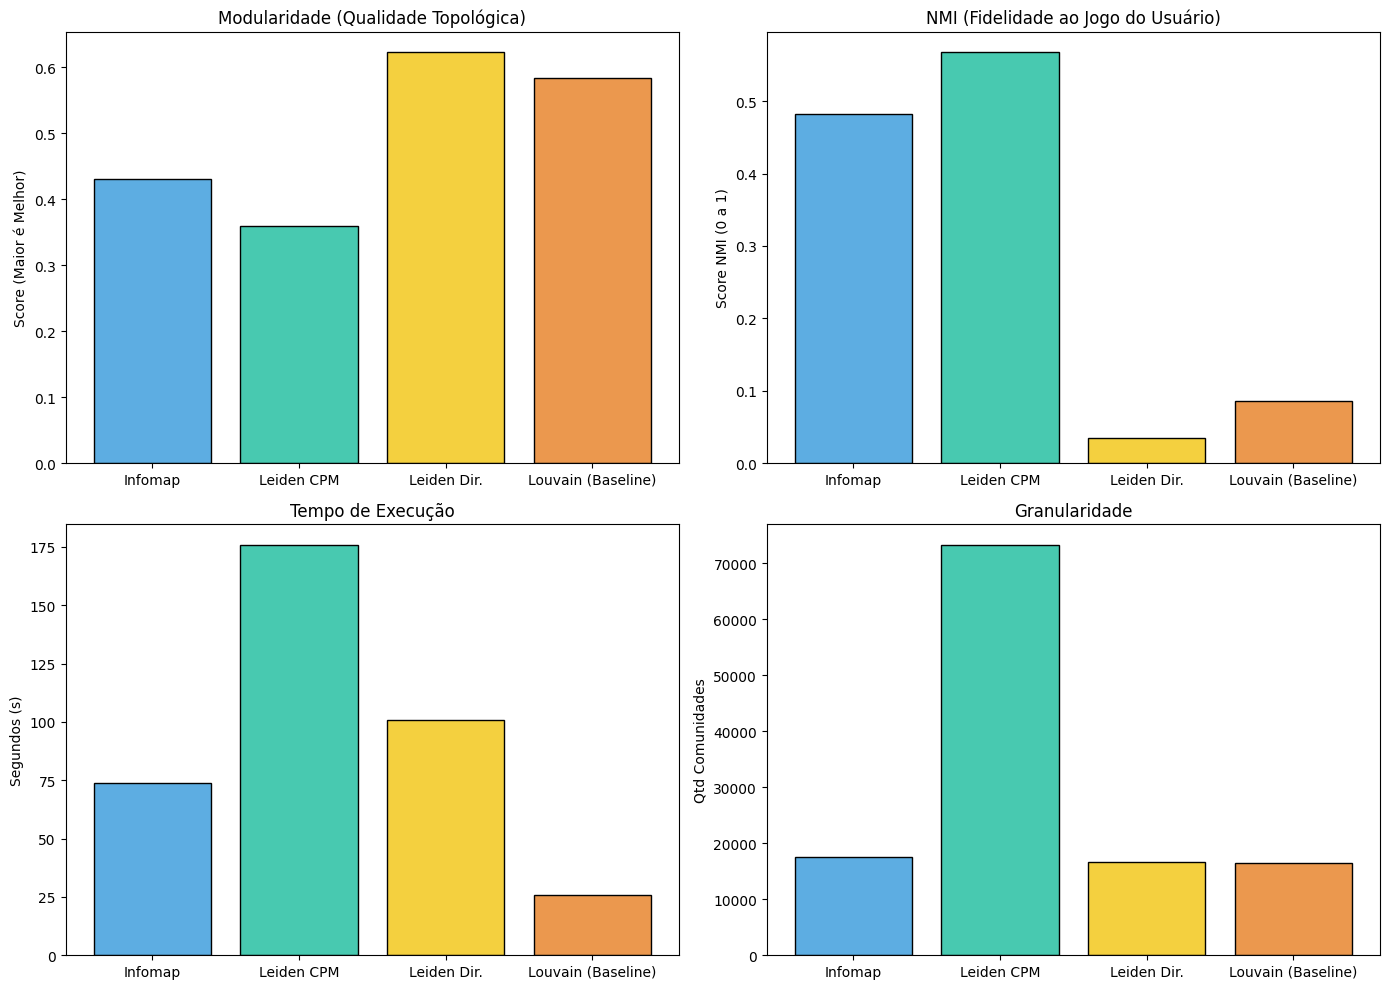

In [ ]:
g_dir, _, g_ig_dir, g_ig_undir, ground_truth = load_graph_and_ground_truth(nodes, edges)

extract_network_statistics(g_ig_dir, g_ig_undir)

results = {}

t, m, nmi, c, infomap_membership = run_infomap_directed(g_dir, g_ig_dir, ground_truth)
results['Infomap'] = {'time': t, 'modularity': m, 'nmi': nmi, 'count': c}

infomap_subgraphs = extract_community_subgraphs(g_dir, g_ig_dir, infomap_membership, min_size=10)

maior_comm_id = max(infomap_subgraphs, key=lambda k: infomap_subgraphs[k].number_of_nodes())
maior_grafo = infomap_subgraphs[maior_comm_id]

print(f"\nAnalisando a maior comunidade do Infomap (ID {maior_comm_id}):")
print(f" -> Jogadores na bolha: {maior_grafo.number_of_nodes()}")
print(f" -> Conexões entre eles: {maior_grafo.number_of_edges()}")

nx.write_graphml(maior_grafo, "maior_comunidade_infomap.graphml")

t, m, nmi, c, leiden_cpm_membership = run_leiden_cpm_directed(g_ig_dir, ground_truth)
results['Leiden CPM'] = {'time': t, 'modularity': m, 'nmi': nmi, 'count': c}

leiden_cpm_subgraphs = extract_community_subgraphs(g_dir, g_ig_dir, leiden_cpm_membership, min_size=10)

maior_comm_id = max(leiden_cpm_subgraphs, key=lambda k: leiden_cpm_subgraphs[k].number_of_nodes())
maior_grafo = leiden_cpm_subgraphs[maior_comm_id]

print(f"\nAnalisando a maior comunidade do Leiden_Cpm (ID {maior_comm_id}):")
print(f" -> Jogadores na bolha: {maior_grafo.number_of_nodes()}")
print(f" -> Conexões entre eles: {maior_grafo.number_of_edges()}")

nx.write_graphml(maior_grafo, "maior_comunidade_leiden_cpm.graphml")

t, m, nmi, c, leiden_membership = run_leiden_directed(g_ig_dir, ground_truth)
results['Leiden Dir.'] = {'time': t, 'modularity': m, 'nmi': nmi, 'count': c}

leiden_subgraphs = extract_community_subgraphs(g_dir, g_ig_dir, leiden_membership, min_size=10)

maior_comm_id = max(leiden_subgraphs, key=lambda k: leiden_subgraphs[k].number_of_nodes())
maior_grafo = leiden_subgraphs[maior_comm_id]

print(f"\nAnalisando a maior comunidade do Leiden (ID {maior_comm_id}):")
print(f" -> Jogadores na bolha: {maior_grafo.number_of_nodes()}")
print(f" -> Conexões entre eles: {maior_grafo.number_of_edges()}")

nx.write_graphml(maior_grafo, "maior_comunidade_leiden.graphml")

t, m, nmi, c, louvain_membership = run_louvain_baseline(g_ig_undir, ground_truth)
results['Louvain (Baseline)'] = {'time': t, 'modularity': m, 'nmi': nmi, 'count': c}

louvain_subgraphs = extract_community_subgraphs(g_dir, g_ig_dir, louvain_membership, min_size=10)

maior_comm_id = max(louvain_subgraphs, key=lambda k: louvain_subgraphs[k].number_of_nodes())
maior_grafo = louvain_subgraphs[maior_comm_id]

print(f"\nAnalisando a maior comunidade do Louvain (ID {maior_comm_id}):")
print(f" -> Jogadores na bolha: {maior_grafo.number_of_nodes()}")
print(f" -> Conexões entre eles: {maior_grafo.number_of_edges()}")

nx.write_graphml(maior_grafo, "maior_comunidade_louvain.graphml")

plot_advanced_dashboard(results)

## Extração de Comunidades

In [6]:
import os
from collections import defaultdict
from collections import Counter
import networkx as nx

def extract_algorithm_communities(G_directed, g_ig_directed, membership_list, min_size=10):
    print(f"\n[Filtro] Extraindo subgrafos baseados no algoritmo (Tamanho mínimo: {min_size})...")

    communities_dict = defaultdict(list)
    for idx, vertex in enumerate(g_ig_directed.vs):
        node_name = vertex['_nx_name']
        comm_id = membership_list[idx]
        communities_dict[comm_id].append(node_name)

    subgraphs = {}
    for comm_id, nodes in communities_dict.items():
        if len(nodes) >= min_size:
            subgraphs[comm_id] = G_directed.subgraph(nodes).copy()

    print(f" -> {len(subgraphs)} subgrafos isolados gerados com sucesso.")
    return subgraphs

def extract_subgraph_by_game(G_directed, target_game):
    print(f"\n[Filtro] Extraindo rede exclusiva do jogo: {target_game}...")

    # Seleciona apenas as arestas que pertencem a este jogo
    valid_edges = [
        (u, v) for u, v, data in G_directed.edges(data=True)
        if data.get('game') == target_game and not data.get('is_profile')
    ]

    # Cria um subgrafo baseado nessas arestas
    game_subgraph = G_directed.edge_subgraph(valid_edges).copy()

    print(f" -> Subgrafo gerado: {game_subgraph.number_of_nodes()} nós e {game_subgraph.number_of_edges()} arestas.")
    return game_subgraph

def extract_profile_network(G_directed):
    print("\n[Filtro] Extraindo rede exclusiva de comentários em perfis (Social pura)...")

    # Seleciona apenas arestas que são comentários de perfil
    valid_edges = [
        (u, v) for u, v, data in G_directed.edges(data=True)
        if data.get('is_profile') and data.get('edge_type') == 'comment'
    ]

    profile_subgraph = G_directed.edge_subgraph(valid_edges).copy()

    print(f" -> Subgrafo gerado: {profile_subgraph.number_of_nodes()} nós e {profile_subgraph.number_of_edges()} arestas.")
    return profile_subgraph

def export_top_games_and_algo_samples(G_directed, g_ig_directed, memberships_dict):
    """
    Exporta os subgrafos dos 10 jogos mais populares e 5 amostras (as maiores) de cada algoritmo.
    Os arquivos são salvos no formato .graphml (compatível com Gephi).
    """
    print("\n" + "="*60)
    print(" 💾 INICIANDO EXPORTAÇÃO EM MASSA DE SUBGRAFOS")
    print("="*60)

    # Criação de pastas para manter seus arquivos organizados
    os.makedirs(f"{BASE_DIR}/results/export_games", exist_ok=True)
    os.makedirs(f"{BASE_DIR}/results/export_algorithms", exist_ok=True)

    # =========================================================
    # PARTE 1: EXTRAIR OS 10 MAIORES JOGOS
    # =========================================================
    print("\n[1/2] Mapeando os 10 jogos mais populares da rede...")

    # Coleta todos os jogos válidos das arestas
    all_games = [
        data.get('game') for u, v, data in G_directed.edges(data=True)
        if data.get('game') and str(data.get('game')).strip() != "unknown"
    ]

    # Encontra os 10 mais frequentes
    top_10_games = [game for game, count in Counter(all_games).most_common(10)]

    for rank, game_name in enumerate(top_10_games, 1):
        # Usamos a função de extração que criamos anteriormente
        subgraph = extract_subgraph_by_game(G_directed, game_name)

        # Limpa o nome do jogo para evitar erro em nomes de arquivo (remove barras e caracteres especiais)
        safe_name = "".join([c for c in game_name if c.isalpha() or c.isdigit() or c==' ']).rstrip()
        filename = f"{BASE_DIR}/results/export_games/top{rank}_{safe_name}.graphml"

        # Salva o arquivo no formato GraphML
        nx.write_graphml(subgraph, filename)
        print(f"   -> Salvo: {filename} ({subgraph.number_of_nodes()} nós)")

    # =========================================================
    # PARTE 2: EXTRAIR 5 AMOSTRAS DE CADA ALGORITMO
    # =========================================================
    print("\n[2/2] Exportando as 5 maiores comunidades de cada algoritmo...")

    for algo_name, membership in memberships_dict.items():
        print(f"\n -> Processando algoritmo: {algo_name}")

        # Extrai todas as comunidades deste algoritmo
        all_subgraphs = extract_algorithm_communities(G_directed, g_ig_directed, membership, min_size=5)

        # Ordena as comunidades pelo tamanho (quantidade de nós), da maior para a menor
        sorted_communities = sorted(all_subgraphs.items(), key=lambda x: x[1].number_of_nodes(), reverse=True)

        # Pega apenas as 5 maiores
        top_5_communities = sorted_communities[:5]

        for idx, (comm_id, subgraph) in enumerate(top_5_communities, 1):
            filename = f"{BASE_DIR}/results/export_algorithms/{algo_name}_amostra{idx}_comm{comm_id}.graphml"
            nx.write_graphml(subgraph, filename)
            print(f"   -> Salvo: {filename} ({subgraph.number_of_nodes()} nós)")

    print("\n" + "="*60)
    print(" ✅ EXPORTAÇÃO CONCLUÍDA! Arquivos prontos nas pastas 'export_games' e 'export_algorithms'.")
    print("="*60)

In [7]:
# 1. Carrega os dados (com a função otimizada que salva os metadados na aresta)
G_dir, G_undir, g_ig_dir, g_ig_undir, ground_truth = load_graph_and_ground_truth(nodes, edges)

# 2. Executa os algoritmos e guarda as listas de comunidades (memberships)
print("Rodando Algoritmos...")
t_im, m_im, nmi_im, c_im, mem_infomap = run_infomap_directed(G_dir, g_ig_dir, ground_truth)
t_lcpm, m_lcpm, nmi_lcpm, c_lcpm, mem_leiden_cpm = run_leiden_cpm_directed(g_ig_dir, ground_truth)
t_lmod, m_lmod, nmi_lmod, c_lmod, mem_leiden_mod = run_leiden_directed(g_ig_dir, ground_truth)
t_louv, m_louv, nmi_louv, c_louv, mem_louvain = run_louvain_baseline(g_ig_undir, ground_truth)

# Opcional: Se rodar o Spinglass, tenha certeza de gerar um membership que alinhe
# com os nós originais, ou pule o Spinglass na extração massiva.

# 3. Cria um dicionário com os resultados
memberships_dos_algoritmos = {
    "Infomap": mem_infomap,
    "LeidenCPM": mem_leiden_cpm,
    "LeidenMod": mem_leiden_mod,
    "Louvain": mem_louvain
}

# 4. Aciona o exportador!
export_top_games_and_algo_samples(G_dir, g_ig_dir, memberships_dos_algoritmos)

1. Carregando arquivos JSON e extraindo Gabarito (Ground Truth)...
   -> Pesos originais: Mín=-1.0 | Máx=0.5726
   -> [Grafo Normalizado] Nós=361444 | Arestas=735098
2. Convertendo para igraph (C++)...
Rodando Algoritmos...

[1/4] Executando Infomap (Fluxo Direcionado - MODO RÁPIDO)...
------------------------------------------------------------
   -> Inserindo arestas no motor do Infomap...
   -> Iniciando as caminhadas aleatórias (Acompanhe abaixo):
------------------------------------------------------------
-> Tempo: 36.83s | Mod Direcionada: 0.5235 | NMI: 0.4583 | Coms: 25729

[2/4] Executando Leiden com CPM (Direcionado e Imune ao Limite de Resolução)...
-> Tempo: 139.93s | Mod Direcionada: 0.4104 | NMI: 0.5608 | Coms: 107996

[3/4] Executando Leiden Direcionado (leidenalg)...
-> Tempo: 72.24s | Mod Direcionada: 0.6844 | NMI: 0.0813 | Coms: 16709

[4/4] Executando Louvain Clássico (Baseline Não-Direcionado)...
-> Tempo: 7.04s | Modularidade: 0.6640 | NMI: 0.0834 | Coms: 16559

 💾